## 1. Install Packages

In [1]:
!pip -q install pyspark kagglehub pandas matplotlib

## 2. Import Libraries

In [2]:
import os
import time
from pathlib import Path

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType
)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Start Apache Spark

In [3]:
spark = (
    SparkSession.builder
    .appName("B142_Olist_Ecommerce_Data_Integration")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)


Spark version: 4.0.4


## 4. Download the Olist Dataset with KaggleHub

In [4]:
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", dataset_path)
print("\nFiles:")
for f in sorted(os.listdir(dataset_path)):
    print(" -", f)


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce

Files:
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_orders_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


## 5. Locate Dataset Files

In [5]:
def find_file(base_path, filename):
    matches = list(Path(base_path).rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {base_path}")
    return str(matches[0])

customers_path = find_file(dataset_path, "olist_customers_dataset.csv")
geolocation_path = find_file(dataset_path, "olist_geolocation_dataset.csv")
order_items_path = find_file(dataset_path, "olist_order_items_dataset.csv")
payments_path = find_file(dataset_path, "olist_order_payments_dataset.csv")
reviews_path = find_file(dataset_path, "olist_order_reviews_dataset.csv")
orders_path = find_file(dataset_path, "olist_orders_dataset.csv")
products_path = find_file(dataset_path, "olist_products_dataset.csv")
sellers_path = find_file(dataset_path, "olist_sellers_dataset.csv")
translation_path = find_file(dataset_path, "product_category_name_translation.csv")

path_dict = {
    "customers": customers_path,
    "geolocation": geolocation_path,
    "order_items": order_items_path,
    "payments": payments_path,
    "reviews": reviews_path,
    "orders": orders_path,
    "products": products_path,
    "sellers": sellers_path,
    "translation": translation_path,
}

for name, path in path_dict.items():
    print(f"{name:14s}: {path}")


customers     : /kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv
geolocation   : /kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv
order_items   : /kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv
payments      : /kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv
reviews       : /kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv
orders        : /kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv
products      : /kaggle/input/brazilian-ecommerce/olist_products_dataset.csv
sellers       : /kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv
translation   : /kaggle/input/brazilian-ecommerce/product_category_name_translation.csv


## 6. Define Explicit Schemas

In [6]:
customers_schema = StructType([
    StructField("customer_id", StringType(), True),
    StructField("customer_unique_id", StringType(), True),
    StructField("customer_zip_code_prefix", IntegerType(), True),
    StructField("customer_city", StringType(), True),
    StructField("customer_state", StringType(), True)
])

orders_schema = StructType([
    StructField("order_id", StringType(), True),
    StructField("customer_id", StringType(), True),
    StructField("order_status", StringType(), True),
    StructField("order_purchase_timestamp", StringType(), True),
    StructField("order_approved_at", StringType(), True),
    StructField("order_delivered_carrier_date", StringType(), True),
    StructField("order_delivered_customer_date", StringType(), True),
    StructField("order_estimated_delivery_date", StringType(), True)
])

order_items_schema = StructType([
    StructField("order_id", StringType(), True),
    StructField("order_item_id", IntegerType(), True),
    StructField("product_id", StringType(), True),
    StructField("seller_id", StringType(), True),
    StructField("shipping_limit_date", StringType(), True),
    StructField("price", DoubleType(), True),
    StructField("freight_value", DoubleType(), True)
])

payments_schema = StructType([
    StructField("order_id", StringType(), True),
    StructField("payment_sequential", IntegerType(), True),
    StructField("payment_type", StringType(), True),
    StructField("payment_installments", IntegerType(), True),
    StructField("payment_value", DoubleType(), True)
])

reviews_schema = StructType([
    StructField("review_id", StringType(), True),
    StructField("order_id", StringType(), True),
    StructField("review_score", IntegerType(), True),
    StructField("review_comment_title", StringType(), True),
    StructField("review_comment_message", StringType(), True),
    StructField("review_creation_date", StringType(), True),
    StructField("review_answer_timestamp", StringType(), True)
])

products_schema = StructType([
    StructField("product_id", StringType(), True),
    StructField("product_category_name", StringType(), True),
    StructField("product_name_lenght", DoubleType(), True),
    StructField("product_description_lenght", DoubleType(), True),
    StructField("product_photos_qty", DoubleType(), True),
    StructField("product_weight_g", DoubleType(), True),
    StructField("product_length_cm", DoubleType(), True),
    StructField("product_height_cm", DoubleType(), True),
    StructField("product_width_cm", DoubleType(), True)
])

sellers_schema = StructType([
    StructField("seller_id", StringType(), True),
    StructField("seller_zip_code_prefix", IntegerType(), True),
    StructField("seller_city", StringType(), True),
    StructField("seller_state", StringType(), True)
])

geolocation_schema = StructType([
    StructField("geolocation_zip_code_prefix", IntegerType(), True),
    StructField("geolocation_lat", DoubleType(), True),
    StructField("geolocation_lng", DoubleType(), True),
    StructField("geolocation_city", StringType(), True),
    StructField("geolocation_state", StringType(), True)
])

translation_schema = StructType([
    StructField("product_category_name", StringType(), True),
    StructField("product_category_name_english", StringType(), True)
])

print("Schemas created.")


Schemas created.


## 7. Extract: Read CSV Files with Spark

In [7]:
def read_csv(path, schema):
    return (
        spark.read
        .option("header", True)
        .option("mode", "PERMISSIVE")
        .schema(schema)
        .csv(path)
    )

customers = read_csv(customers_path, customers_schema)
orders_raw = read_csv(orders_path, orders_schema)
order_items_raw = read_csv(order_items_path, order_items_schema)
payments_raw = read_csv(payments_path, payments_schema)
reviews_raw = read_csv(reviews_path, reviews_schema)
products = read_csv(products_path, products_schema)
sellers = read_csv(sellers_path, sellers_schema)
geolocation = read_csv(geolocation_path, geolocation_schema)
translation = read_csv(translation_path, translation_schema)

datasets = {
    "customers": customers,
    "orders": orders_raw,
    "order_items": order_items_raw,
    "payments": payments_raw,
    "reviews": reviews_raw,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "translation": translation
}

print("All nine CSV datasets loaded.")


All nine CSV datasets loaded.


## 8. Raw Data Inventory

In [8]:
inventory = []

for name, df in datasets.items():
    inventory.append({
        "dataset": name,
        "rows": df.count(),
        "columns": len(df.columns)
    })

inventory_df = pd.DataFrame(inventory).sort_values("dataset")
display(inventory_df)


,dataset,rows,columns
0,customers,99441,5
7,geolocation,1000163,5
2,order_items,112650,7
1,orders,99441,8
3,payments,103886,5
5,products,32951,9
4,reviews,104162,7
6,sellers,3095,4
8,translation,71,2


## 9. Schema Inspection

In [9]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    df.printSchema()



customers
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


orders
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: string (nullable = true)
 |-- order_approved_at: string (nullable = true)
 |-- order_delivered_carrier_date: string (nullable = true)
 |-- order_delivered_customer_date: string (nullable = true)
 |-- order_estimated_delivery_date: string (nullable = true)


order_items
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: string (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = 

## 10. Preview Key Tables

In [10]:
for name in [
    "orders", "customers", "order_items",
    "products", "payments", "reviews", "sellers"
]:
    print("\n" + "=" * 70)
    print(name)
    datasets[name].show(5, truncate=False)



orders
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07

## 11. Null-Value Assessment

In [11]:
def null_summary(df):
    return df.select([
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ])

def null_summary_long(df, dataset_name):
    row = null_summary(df).collect()[0].asDict()
    return pd.DataFrame([
        {
            "dataset": dataset_name,
            "column": c,
            "null_count": int(v or 0)
        }
        for c, v in row.items()
    ])

null_report = pd.concat(
    [
        null_summary_long(df, name)
        for name, df in datasets.items()
    ],
    ignore_index=True
)

display(
    null_report[null_report["null_count"] > 0]
    .sort_values(["dataset", "null_count"], ascending=[True, False])
)


,dataset,column,null_count
11,orders,order_delivered_customer_date,2965
10,orders,order_delivered_carrier_date,1783
9,orders,order_approved_at,160
33,products,product_category_name,610
34,products,product_name_lenght,610
35,products,product_description_lenght,610
36,products,product_photos_qty,610
37,products,product_weight_g,2
38,products,product_length_cm,2
39,products,product_height_cm,2


## 12. Duplicate Assessment

In [12]:
duplicate_report = []

for name, df in datasets.items():
    total = df.count()
    distinct = df.dropDuplicates().count()
    duplicate_report.append({
        "dataset": name,
        "rows": total,
        "distinct_rows": distinct,
        "duplicate_rows": total - distinct
    })

display(pd.DataFrame(duplicate_report))


,dataset,rows,distinct_rows,duplicate_rows
0,customers,99441,99441,0
1,orders,99441,99441,0
2,order_items,112650,112650,0
3,payments,103886,103886,0
4,reviews,104162,104071,91
5,products,32951,32951,0
6,sellers,3095,3095,0
7,geolocation,1000163,738332,261831
8,translation,71,71,0


## 13. Transform Orders: Explicit Timestamp Conversion

In [13]:
timestamp_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders = orders_raw

for c in timestamp_columns:
    orders = orders.withColumn(
        c,
        F.to_timestamp(F.col(c))
    )

orders.printSchema()


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



## 14. Feature Engineering: Delivery Metrics

In [14]:
orders = (
    orders
    .withColumn(
        "delivery_days",
        F.datediff(
            F.to_date("order_delivered_customer_date"),
            F.to_date("order_purchase_timestamp")
        )
    )
    .withColumn(
        "delivery_delay_days",
        F.datediff(
            F.to_date("order_delivered_customer_date"),
            F.to_date("order_estimated_delivery_date")
        )
    )
    .withColumn(
        "delivery_performance",
        F.when(F.col("delivery_delay_days").isNull(), "Unknown")
         .when(F.col("delivery_delay_days") < 0, "Early")
         .when(F.col("delivery_delay_days") == 0, "On Time")
         .otherwise("Late")
    )
)

orders.select(
    "order_id",
    "delivery_days",
    "delivery_delay_days",
    "delivery_performance"
).show(10)


+--------------------+-------------+-------------------+--------------------+
|            order_id|delivery_days|delivery_delay_days|delivery_performance|
+--------------------+-------------+-------------------+--------------------+
|e481f51cbdc54678b...|            8|                 -8|               Early|
|53cdb2fc8bc7dce0b...|           14|                 -6|               Early|
|47770eb9100c2d0c4...|            9|                -18|               Early|
|949d5b44dbf5de918...|           14|                -13|               Early|
|ad21c59c0840e6cb8...|            3|                -10|               Early|
|a4591c265e18cb1dc...|           17|                 -6|               Early|
|136cce7faa42fdb2c...|         NULL|               NULL|             Unknown|
|6514b8ad8028c9f2c...|           10|                -12|               Early|
|76c6e866289321a7c...|           10|                -32|               Early|
|e69bfb5eb88e0ed6a...|           18|                 -7|        

## 15. Clean Customers

In [15]:
customers_clean = (
    customers
    .dropDuplicates(["customer_id"])
    .filter(F.col("customer_id").isNotNull())
    .filter(F.col("customer_unique_id").isNotNull())
)

print("Clean customer rows:", customers_clean.count())


Clean customer rows: 99441


## 16. Clean and Prepare Order Items

In [16]:
order_items = (
    order_items_raw
    .withColumn(
        "shipping_limit_date",
        F.to_timestamp("shipping_limit_date")
    )
    .filter(F.col("order_id").isNotNull())
    .filter(F.col("product_id").isNotNull())
    .filter(F.col("price").isNotNull())
    .filter(F.col("price") >= 0)
    .filter(F.col("freight_value").isNotNull())
    .filter(F.col("freight_value") >= 0)
)

products_clean = (
    products
    .dropDuplicates(["product_id"])
    .filter(F.col("product_id").isNotNull())
)

print("Clean order-item rows:", order_items.count())
print("Clean product rows:", products_clean.count())


Clean order-item rows: 112650
Clean product rows: 32951


## 17. Aggregate Order Value

In [17]:
order_value = (
    order_items
    .groupBy("order_id")
    .agg(
        F.round(F.sum("price"), 2).alias("product_value"),
        F.round(F.sum("freight_value"), 2).alias("freight_value"),
        F.countDistinct("order_item_id").alias("number_of_items")
    )
)

order_value.show(10)


+--------------------+-------------+-------------+---------------+
|            order_id|product_value|freight_value|number_of_items|
+--------------------+-------------+-------------+---------------+
|00276d5c3491fbf55...|         44.9|        23.22|              1|
|00526a9d4ebde463b...|       135.56|         33.6|              4|
|00891ba5de66f5500...|        133.0|        16.69|              1|
|00949655cdd8d0465...|         18.0|         7.87|              1|
|00a250dbdb3153cc6...|        53.99|         7.78|              1|
|00f57f2ccce2a2e3f...|        225.0|        60.81|              1|
|00f621226c6f4e938...|        199.0|        32.79|              1|
|00fed9e582d5a3e38...|       359.98|         52.2|              2|
|0108fba93678555ad...|        199.0|        20.12|              1|
|012a238ab54294a3b...|        137.7|        38.07|              3|
+--------------------+-------------+-------------+---------------+
only showing top 10 rows


## 18. Aggregate Payments

In [18]:
payments = (
    payments_raw
    .filter(F.col("order_id").isNotNull())
    .filter(F.col("payment_value").isNotNull())
    .filter(F.col("payment_value") >= 0)
)

payment_summary = (
    payments
    .groupBy("order_id")
    .agg(
        F.round(F.sum("payment_value"), 2).alias("payment_value"),
        F.countDistinct("payment_sequential").alias("payment_count"),
        F.first("payment_type", ignorenulls=True).alias("primary_payment_type")
    )
)

payment_summary.show(10)


+--------------------+-------------+-------------+--------------------+
|            order_id|payment_value|payment_count|primary_payment_type|
+--------------------+-------------+-------------+--------------------+
|00010242fe8c5a6d1...|        72.19|            1|         credit_card|
|000229ec398224ef6...|       216.87|            1|         credit_card|
|00042b26cf59d7ce6...|       218.04|            1|         credit_card|
|00048cc3ae777c65d...|        34.59|            1|              boleto|
|0005f50442cb953dc...|        65.39|            1|         credit_card|
|00061f2a7bc09da83...|        68.87|            1|         credit_card|
|00063b381e2406b52...|        57.98|            1|         credit_card|
|0009792311464db53...|       127.55|            1|              boleto|
|000c3e6612759851c...|       112.71|            1|              boleto|
|000f25f4d72195062...|       164.39|            1|         credit_card|
+--------------------+-------------+-------------+--------------

## 19. Aggregate Reviews

In [19]:
reviews = (
    reviews_raw
    .withColumn(
        "review_creation_date",
        F.to_timestamp("review_creation_date")
    )
    .withColumn(
        "review_answer_timestamp",
        F.to_timestamp("review_answer_timestamp")
    )
    .filter(F.col("order_id").isNotNull())
    .filter(F.col("review_score").between(1, 5))
)

review_summary = (
    reviews
    .groupBy("order_id")
    .agg(
        F.round(F.avg("review_score"), 2).alias("average_review_score"),
        F.countDistinct("review_id").alias("review_count")
    )
)

review_summary.show(10)


+--------------------+--------------------+------------+
|            order_id|average_review_score|review_count|
+--------------------+--------------------+------------+
|366df9c0b0d5d46f8...|                 4.0|           1|
|a6ab143f24e590dc7...|                 4.0|           1|
|0bcbcc3e0a09b3f6a...|                 5.0|           1|
|51eaae3287e04efba...|                 1.0|           1|
|7368e14d8b9e7b886...|                 3.0|           1|
|9dd961aa6268f666f...|                 5.0|           1|
|a0c370a65210b6a6e...|                 1.0|           1|
|833aeeba583417aa6...|                 5.0|           1|
|abb71252913999175...|                 4.0|           1|
|6e8e751584b3e3141...|                 5.0|           1|
+--------------------+--------------------+------------+
only showing top 10 rows


## 20. Integrate Orders and Customers

In [20]:
orders_customers = (
    orders.alias("o")
    .join(
        customers_clean.alias("c"),
        F.col("o.customer_id") == F.col("c.customer_id"),
        "left"
    )
    .select(
        F.col("o.order_id"),
        F.col("o.customer_id"),
        F.col("o.order_status"),
        F.col("o.order_purchase_timestamp"),
        F.col("o.order_approved_at"),
        F.col("o.order_delivered_carrier_date"),
        F.col("o.order_delivered_customer_date"),
        F.col("o.order_estimated_delivery_date"),
        F.col("o.delivery_days"),
        F.col("o.delivery_delay_days"),
        F.col("o.delivery_performance"),
        F.col("c.customer_unique_id"),
        F.col("c.customer_zip_code_prefix"),
        F.col("c.customer_city"),
        F.col("c.customer_state")
    )
)

orders_customers.printSchema()


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delivery_performance: string (nullable = false)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)



## 21. Build the Final Order-Level Analytical Dataset

In [21]:
integrated_orders = (
    orders_customers
    .join(order_value, "order_id", "left")
    .join(payment_summary, "order_id", "left")
    .join(review_summary, "order_id", "left")
    .select(
        "order_id",
        "customer_id",
        "customer_unique_id",
        "customer_zip_code_prefix",
        "customer_city",
        "customer_state",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "delivery_delay_days",
        "delivery_performance",
        "product_value",
        "freight_value",
        "number_of_items",
        "payment_value",
        "payment_count",
        "primary_payment_type",
        "average_review_score",
        "review_count"
    )
)

print("Integrated order-level rows:", integrated_orders.count())
integrated_orders.printSchema()


Integrated order-level rows: 99441
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delivery_performance: string (nullable = false)
 |-- product_value: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- number_of_items: long (nullable = true)
 |-- payment_value: double (nullable = true)
 |

## 22. Validate Final Analytical Data Before Writing

In [22]:
print("Representative records:")
integrated_orders.select(
    "order_id",
    "order_purchase_timestamp",
    "product_value",
    "freight_value",
    "payment_value",
    "average_review_score",
    "delivery_days",
    "delivery_delay_days"
).show(10, truncate=False)

print("\nKey datatypes:")
for c in [
    "product_value",
    "freight_value",
    "number_of_items",
    "payment_value",
    "payment_count",
    "average_review_score",
    "review_count",
    "delivery_days",
    "delivery_delay_days"
]:
    print(f"{c:25s} -> {integrated_orders.schema[c].dataType}")


Representative records:
+--------------------------------+------------------------+-------------+-------------+-------------+--------------------+-------------+-------------------+
|order_id                        |order_purchase_timestamp|product_value|freight_value|payment_value|average_review_score|delivery_days|delivery_delay_days|
+--------------------------------+------------------------+-------------+-------------+-------------+--------------------+-------------+-------------------+
|e481f51cbdc54678b7cc49136f2d6af7|2017-10-02 10:56:33     |29.99        |8.72         |38.71        |4.0                 |8            |-8                 |
|53cdb2fc8bc7dce0b6741e2150273451|2018-07-24 20:41:37     |118.7        |22.76        |141.46       |4.0                 |14           |-6                 |
|47770eb9100c2d0c44946d9cf07ec65d|2018-08-08 08:38:49     |159.9        |19.22        |179.12       |5.0                 |9            |-18                |
|949d5b44dbf5de918fe9c16f97b45f8a|

## 23. Final Null and Duplicate Checks

In [23]:
print("Final null profile:")
display(
    null_summary_long(
        integrated_orders,
        "integrated_orders"
    ).sort_values("null_count", ascending=False).head(20)
)

total_rows = integrated_orders.count()
distinct_order_ids = integrated_orders.select("order_id").distinct().count()

print("Total order-level rows:", total_rows)
print("Distinct order IDs:", distinct_order_ids)
print("Duplicate order IDs:", total_rows - distinct_order_ids)


Final null profile:


,dataset,column,null_count
13,integrated_orders,delivery_delay_days,2965
12,integrated_orders,delivery_days,2965
10,integrated_orders,order_delivered_customer_date,2965
9,integrated_orders,order_delivered_carrier_date,1783
15,integrated_orders,product_value,775
17,integrated_orders,number_of_items,775
16,integrated_orders,freight_value,775
21,integrated_orders,average_review_score,768
22,integrated_orders,review_count,768
8,integrated_orders,order_approved_at,160


Total order-level rows: 99441
Distinct order IDs: 99441
Duplicate order IDs: 0


## 24. ETL Load: Write Order-Level Data to Parquet

In [24]:
OUTPUT_ROOT = "/content/olist_output"
ORDER_PARQUET_PATH = f"{OUTPUT_ROOT}/order_level"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

integrated_orders.write     .mode("overwrite")     .parquet(ORDER_PARQUET_PATH)

print("Order-level Parquet created:", ORDER_PARQUET_PATH)


Order-level Parquet created: /content/olist_output/order_level


## 25. Read Parquet Back and Verify

In [25]:
processed_orders = spark.read.parquet(ORDER_PARQUET_PATH)

print("Rows read from Parquet:", processed_orders.count())
processed_orders.printSchema()
processed_orders.show(5, truncate=False)


Rows read from Parquet: 99441
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- delivery_days: integer (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delivery_performance: string (nullable = true)
 |-- product_value: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- number_of_items: long (nullable = true)
 |-- payment_value: double (nullable = true)
 |-- pay

## 26. Build Item-Level Integrated Dataset

In [26]:
item_product = (
    order_items.alias("oi")
    .join(
        products_clean.alias("p"),
        F.col("oi.product_id") == F.col("p.product_id"),
        "left"
    )
    .join(
        translation.alias("t"),
        F.col("p.product_category_name") == F.col("t.product_category_name"),
        "left"
    )
    .join(
        sellers.alias("s"),
        F.col("oi.seller_id") == F.col("s.seller_id"),
        "left"
    )
    .select(
        F.col("oi.order_id"),
        F.col("oi.order_item_id"),
        F.col("oi.product_id"),
        F.col("oi.seller_id"),
        F.col("oi.shipping_limit_date"),
        F.col("oi.price"),
        F.col("oi.freight_value"),
        F.col("p.product_category_name"),
        F.col("t.product_category_name_english"),
        F.col("p.product_weight_g"),
        F.col("p.product_length_cm"),
        F.col("p.product_height_cm"),
        F.col("p.product_width_cm"),
        F.col("s.seller_zip_code_prefix"),
        F.col("s.seller_city"),
        F.col("s.seller_state")
    )
)

print("Item-level rows:", item_product.count())
item_product.printSchema()


Item-level rows: 112650
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)
 |-- product_weight_g: double (nullable = true)
 |-- product_length_cm: double (nullable = true)
 |-- product_height_cm: double (nullable = true)
 |-- product_width_cm: double (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)



## 27. Save Item-Level Dataset as Parquet

In [27]:
ITEM_PARQUET_PATH = f"{OUTPUT_ROOT}/item_level"

item_product.write     .mode("overwrite")     .parquet(ITEM_PARQUET_PATH)

print("Item-level Parquet created:", ITEM_PARQUET_PATH)


Item-level Parquet created: /content/olist_output/item_level


## 28. Create Spark SQL Views

In [28]:
processed_orders.createOrReplaceTempView("olist_orders")
item_product.createOrReplaceTempView("olist_items")

print("Views created: olist_orders, olist_items")


Views created: olist_orders, olist_items


## 29. Spark SQL Analytics: Orders by Status

In [29]:
orders_by_status = spark.sql("""
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM olist_orders
GROUP BY order_status
ORDER BY total_orders DESC
""")

orders_by_status.show()


+------------+------------+
|order_status|total_orders|
+------------+------------+
|   delivered|       96478|
|     shipped|        1107|
|    canceled|         625|
| unavailable|         609|
|    invoiced|         314|
|  processing|         301|
|     created|           5|
|    approved|           2|
+------------+------------+



## 30. Spark SQL Analytics: Monthly Orders

In [30]:
monthly_orders = spark.sql("""
SELECT
    YEAR(order_purchase_timestamp) AS order_year,
    MONTH(order_purchase_timestamp) AS order_month,
    COUNT(*) AS total_orders
FROM olist_orders
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY YEAR(order_purchase_timestamp),
         MONTH(order_purchase_timestamp)
ORDER BY order_year, order_month
""")

monthly_orders.show(50)


+----------+-----------+------------+
|order_year|order_month|total_orders|
+----------+-----------+------------+
|      2016|          9|           4|
|      2016|         10|         324|
|      2016|         12|           1|
|      2017|          1|         800|
|      2017|          2|        1780|
|      2017|          3|        2682|
|      2017|          4|        2404|
|      2017|          5|        3700|
|      2017|          6|        3245|
|      2017|          7|        4026|
|      2017|          8|        4331|
|      2017|          9|        4285|
|      2017|         10|        4631|
|      2017|         11|        7544|
|      2017|         12|        5673|
|      2018|          1|        7269|
|      2018|          2|        6728|
|      2018|          3|        7211|
|      2018|          4|        6939|
|      2018|          5|        6873|
|      2018|          6|        6167|
|      2018|          7|        6292|
|      2018|          8|        6512|
|      2018|

## 31. Spark SQL Analytics: Financial Summary

In [31]:
financial_summary = spark.sql("""
SELECT
    ROUND(SUM(product_value), 2) AS total_product_value,
    ROUND(SUM(freight_value), 2) AS total_freight_value,
    ROUND(AVG(product_value), 2) AS average_product_value,
    ROUND(AVG(number_of_items), 2) AS average_items_per_order
FROM olist_orders
""")

financial_summary.show()


+-------------------+-------------------+---------------------+-----------------------+
|total_product_value|total_freight_value|average_product_value|average_items_per_order|
+-------------------+-------------------+---------------------+-----------------------+
|       1.35916437E7|         2251909.54|               137.75|                   1.14|
+-------------------+-------------------+---------------------+-----------------------+



## 32. Spark SQL Analytics: Payment Methods

In [32]:
payment_methods = spark.sql("""
SELECT
    primary_payment_type,
    COUNT(*) AS total_orders,
    ROUND(SUM(payment_value), 2) AS total_payment_value
FROM olist_orders
WHERE primary_payment_type IS NOT NULL
GROUP BY primary_payment_type
ORDER BY total_orders DESC
""")

payment_methods.show()


+--------------------+------------+-------------------+
|primary_payment_type|total_orders|total_payment_value|
+--------------------+------------+-------------------+
|         credit_card|       75880|      1.264266121E7|
|              boleto|       19784|         2869361.27|
|             voucher|        2245|          278757.03|
|          debit_card|        1528|          218092.61|
|         not_defined|           3|                0.0|
+--------------------+------------+-------------------+



## 33. Spark SQL Analytics: Delivery Performance

In [33]:
delivery_summary = spark.sql("""
SELECT
    delivery_performance,
    COUNT(*) AS total_orders,
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days,
    ROUND(AVG(delivery_delay_days), 2) AS avg_delay_days
FROM olist_orders
GROUP BY delivery_performance
ORDER BY total_orders DESC
""")

delivery_summary.show()


+--------------------+------------+-----------------+--------------+
|delivery_performance|total_orders|avg_delivery_days|avg_delay_days|
+--------------------+------------+-----------------+--------------+
|               Early|       88649|            10.82|        -13.71|
|                Late|        6535|            33.91|         10.62|
|             Unknown|        2965|             NULL|          NULL|
|             On Time|        1292|            19.17|           0.0|
+--------------------+------------+-----------------+--------------+



## 34. Spark SQL Analytics: Customer State

In [34]:
state_orders = spark.sql("""
SELECT
    customer_state,
    COUNT(*) AS total_orders,
    ROUND(SUM(product_value), 2) AS total_product_value
FROM olist_orders
WHERE customer_state IS NOT NULL
GROUP BY customer_state
ORDER BY total_orders DESC
""")

state_orders.show(15)


+--------------+------------+-------------------+
|customer_state|total_orders|total_product_value|
+--------------+------------+-------------------+
|            SP|       41746|         5202955.05|
|            RJ|       12852|         1824092.67|
|            MG|       11635|         1585308.03|
|            RS|        5466|          750304.02|
|            PR|        5045|          683083.76|
|            SC|        3637|          520553.34|
|            BA|        3380|          511349.99|
|            DF|        2140|          302603.94|
|            ES|        2033|          275037.31|
|            GO|        2020|          294591.95|
|            PE|        1652|          262788.03|
|            CE|        1336|          227254.71|
|            PA|         975|          178947.81|
|            MT|         907|          156453.53|
|            MA|         747|          119648.22|
+--------------+------------+-------------------+
only showing top 15 rows


## 35. Spark SQL Analytics: Product Categories

In [35]:
category_performance = spark.sql("""
SELECT
    COALESCE(
        product_category_name_english,
        product_category_name,
        'Unknown'
    ) AS category,
    COUNT(*) AS total_items,
    ROUND(SUM(price), 2) AS product_value,
    ROUND(AVG(price), 2) AS average_item_price,
    ROUND(SUM(freight_value), 2) AS total_freight
FROM olist_items
GROUP BY COALESCE(
    product_category_name_english,
    product_category_name,
    'Unknown'
)
ORDER BY product_value DESC
""")

category_performance.show(20, truncate=False)


+---------------------+-----------+-------------+------------------+-------------+
|category             |total_items|product_value|average_item_price|total_freight|
+---------------------+-----------+-------------+------------------+-------------+
|health_beauty        |9670       |1258681.34   |130.16            |182566.73    |
|watches_gifts        |5991       |1205005.68   |201.14            |100535.93    |
|bed_bath_table       |11115      |1036988.68   |93.3              |204693.04    |
|sports_leisure       |8641       |988048.97    |114.34            |168607.51    |
|computers_accessories|7827       |911954.32    |116.51            |147318.08    |
|furniture_decor      |8334       |729762.49    |87.56             |172749.3     |
|cool_stuff           |3796       |635290.85    |167.36            |84039.1      |
|housewares           |6964       |632248.66    |90.79             |146149.11    |
|auto                 |4235       |592720.11    |139.96            |92664.21     |
|gar

## 36. Spark SQL Analytics: Review Scores

In [36]:
review_distribution = spark.sql("""
SELECT
    CAST(average_review_score AS INT) AS review_score,
    COUNT(*) AS total_orders
FROM olist_orders
WHERE average_review_score IS NOT NULL
GROUP BY CAST(average_review_score AS INT)
ORDER BY review_score
""")

review_distribution.show()


+------------+------------+
|review_score|total_orders|
+------------+------------+
|           1|       11324|
|           2|        3159|
|           3|        8162|
|           4|       19073|
|           5|       56955|
+------------+------------+



## 37. Spark SQL Analytics: Delivery vs Satisfaction

In [37]:
delivery_reviews = spark.sql("""
SELECT
    delivery_performance,
    COUNT(*) AS total_orders,
    ROUND(AVG(average_review_score), 2) AS avg_review_score
FROM olist_orders
WHERE average_review_score IS NOT NULL
GROUP BY delivery_performance
ORDER BY avg_review_score DESC
""")

delivery_reviews.show()


+--------------------+------------+----------------+
|delivery_performance|total_orders|avg_review_score|
+--------------------+------------+----------------+
|               Early|       88168|            4.29|
|             On Time|        1280|            4.04|
|                Late|        6382|            2.27|
|             Unknown|        2843|            1.75|
+--------------------+------------+----------------+



## 38. Visualisation: Monthly Orders

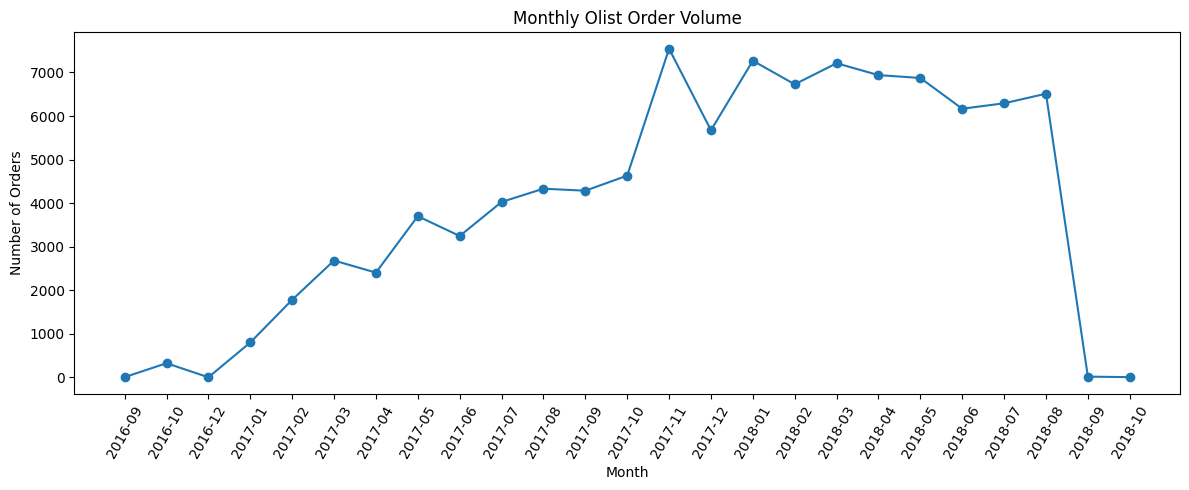

In [38]:
monthly_pd = monthly_orders.toPandas()
monthly_pd["period"] = (
    monthly_pd["order_year"].astype(str)
    + "-"
    + monthly_pd["order_month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_pd["period"],
    monthly_pd["total_orders"],
    marker="o"
)
plt.xticks(rotation=60)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Olist Order Volume")
plt.tight_layout()
plt.show()


## 39. Visualisation: Top Product Categories

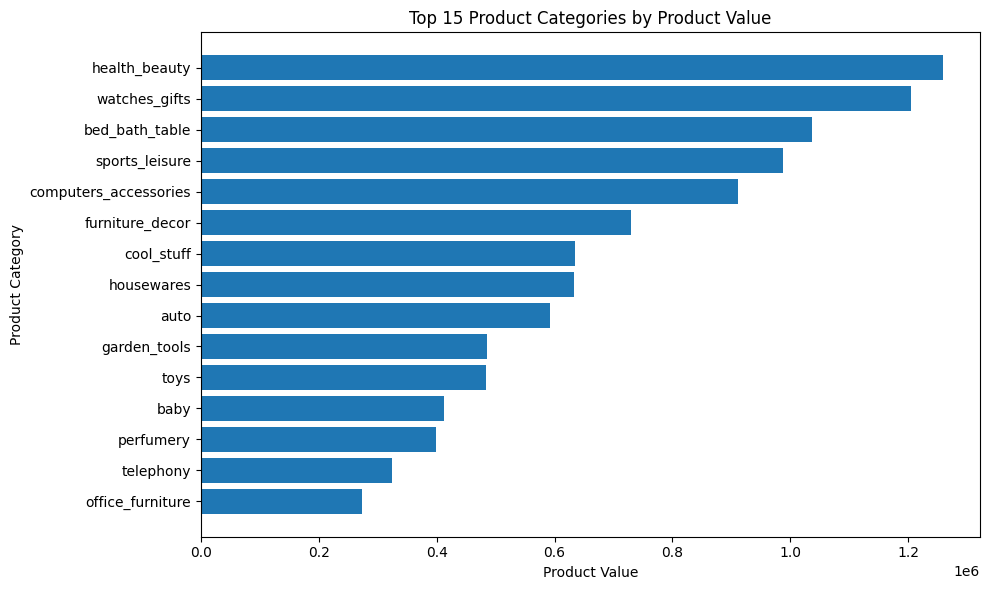

In [39]:
category_pd = (
    category_performance
    .limit(15)
    .toPandas()
    .sort_values("product_value")
)

plt.figure(figsize=(10, 6))
plt.barh(
    category_pd["category"],
    category_pd["product_value"]
)
plt.xlabel("Product Value")
plt.ylabel("Product Category")
plt.title("Top 15 Product Categories by Product Value")
plt.tight_layout()
plt.show()


## 40. Visualisation: Top Customer States

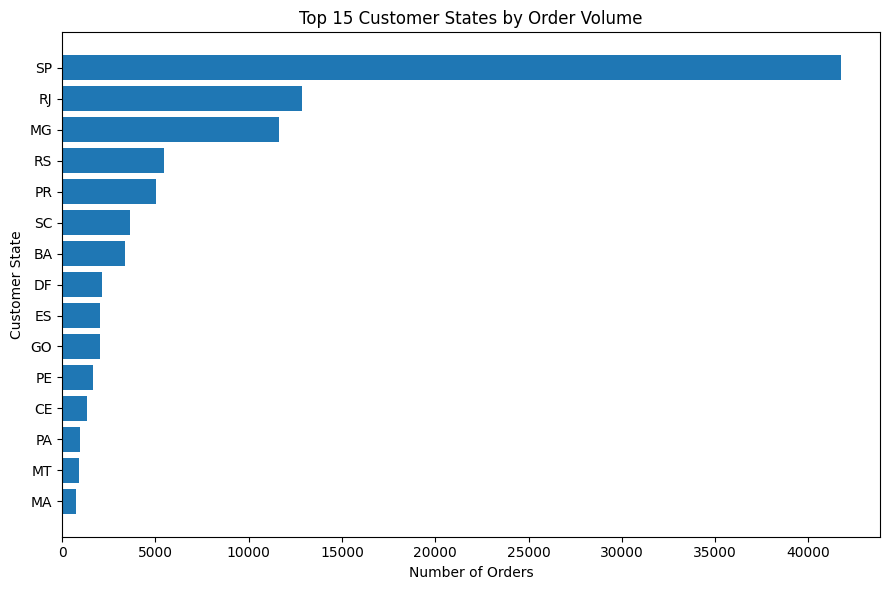

In [40]:
state_pd = (
    state_orders
    .limit(15)
    .toPandas()
    .sort_values("total_orders")
)

plt.figure(figsize=(9, 6))
plt.barh(
    state_pd["customer_state"],
    state_pd["total_orders"]
)
plt.xlabel("Number of Orders")
plt.ylabel("Customer State")
plt.title("Top 15 Customer States by Order Volume")
plt.tight_layout()
plt.show()


## 41. Visualisation: Review Score Distribution

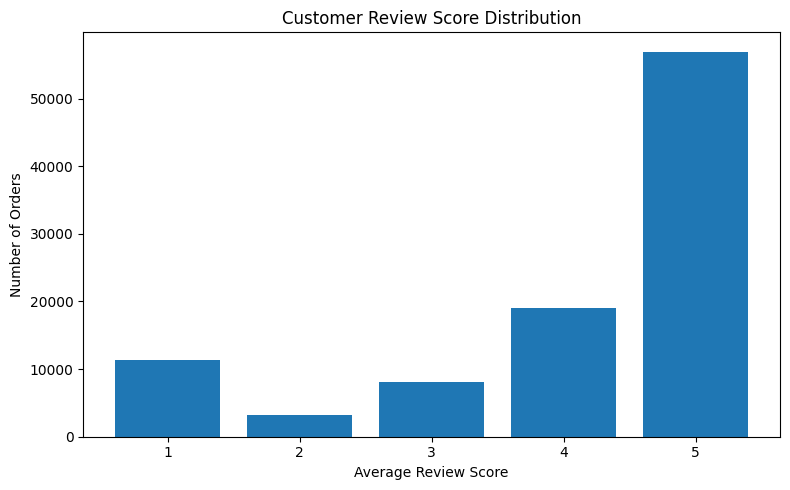

In [41]:
review_pd = review_distribution.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    review_pd["review_score"].astype(str),
    review_pd["total_orders"]
)
plt.xlabel("Average Review Score")
plt.ylabel("Number of Orders")
plt.title("Customer Review Score Distribution")
plt.tight_layout()
plt.show()


## 42. Visualisation: Delivery Performance

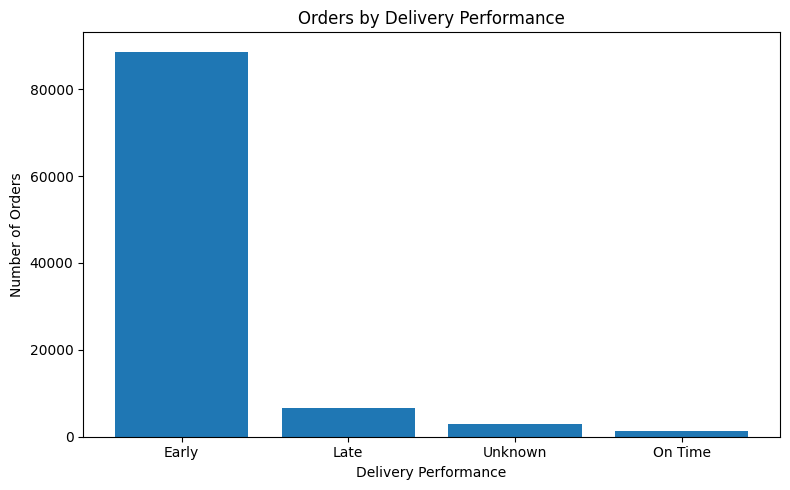

In [42]:
delivery_pd = delivery_summary.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    delivery_pd["delivery_performance"],
    delivery_pd["total_orders"]
)
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")
plt.title("Orders by Delivery Performance")
plt.tight_layout()
plt.show()


## 43. Performance Observation

In [43]:
start = time.perf_counter()

benchmark = (
    processed_orders
    .groupBy("order_status")
    .count()
    .orderBy(F.desc("count"))
    .collect()
)

elapsed = time.perf_counter() - start

print("Benchmark output:", benchmark)
print(f"Measured Spark aggregation time: {elapsed:.3f} seconds")


Benchmark output: [Row(order_status='delivered', count=96478), Row(order_status='shipped', count=1107), Row(order_status='canceled', count=625), Row(order_status='unavailable', count=609), Row(order_status='invoiced', count=314), Row(order_status='processing', count=301), Row(order_status='created', count=5), Row(order_status='approved', count=2)]
Measured Spark aggregation time: 0.265 seconds


## 44. Partition Check

In [44]:
print("Current number of partitions:", processed_orders.rdd.getNumPartitions())

test_df = processed_orders.repartition(8)

print("Partitions after repartition(8):", test_df.rdd.getNumPartitions())


Current number of partitions: 2
Partitions after repartition(8): 8


## 45. Final Output Summary

In [45]:
print("=" * 70)
print("FINAL PROJECT OUTPUT SUMMARY")
print("=" * 70)

print("Spark version:", spark.version)
print("KaggleHub dataset path:", dataset_path)
print("Order-level rows:", processed_orders.count())
print("Item-level rows:", item_product.count())
print("Order Parquet:", ORDER_PARQUET_PATH)
print("Item Parquet:", ITEM_PARQUET_PATH)

print("\nOrder-level columns:")
print(processed_orders.columns)

print("\nItem-level columns:")
print(item_product.columns)


FINAL PROJECT OUTPUT SUMMARY
Spark version: 4.0.4
KaggleHub dataset path: /kaggle/input/brazilian-ecommerce
Order-level rows: 99441
Item-level rows: 112650
Order Parquet: /content/olist_output/order_level
Item Parquet: /content/olist_output/item_level

Order-level columns:
['order_id', 'customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delivery_delay_days', 'delivery_performance', 'product_value', 'freight_value', 'number_of_items', 'payment_value', 'payment_count', 'primary_payment_type', 'average_review_score', 'review_count']

Item-level columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_

## 47. Stop Spark

In [46]:
spark.stop()
print("Spark session stopped.")


Spark session stopped.
